# Failure Analysis: SAE-Based Investigation of Probe Errors

Mechanistic analysis of why activation probes fail using Sparse Autoencoders (Llama Scope).

**Research Questions:**
1. Why do probes fail? (Specific features/patterns)
2. Are failures interpretable? (SAE feature explanations)
3. Are failures systematic? (Clusters vs random)
4. Does language matter? (Original vs ID mechanisms)

**Methodology:**
- Load probe predictions from notebook 05 results
- Categorize failures: consistent (Original+ID wrong) vs language-specific
- Extract SAE features for failure cases
- Map failures to interpretable features via Neuronpedia

**Based on paper failure modes (arXiv:2506.10805):**
- Signal word false positives (e.g., "emergency" triggers high-stakes)
- Humor masking (jokes reduce probe scores)
- Ethical framing ("responsible money laundering")
- Context mixing (high-stakes buried in low-stakes)

## Part 0: Setup

In [1]:
import importlib
missing = [pkg for pkg in ["umap", "sae_lens"] if not importlib.util.find_spec(pkg)]
if missing:
    %pip install -U umap-learn sae-lens

In [2]:
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import umap
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

sys.path.insert(0, str(Path("..").resolve()))

from lib.env import resolve_base_dir, setup_paths, setup_hf_auth
from lib.data import load_dataset, load_jsonl
from lib.model import load_model, get_model_short_name
from lib.probe import LinearProbe
from lib.neuronpedia import fetch_explanations, llama_scope_sae_id, format_feature_with_explanation

# --- Configuration ---
MODEL_NAME      = "meta-llama/Llama-3.1-8B-Instruct"
LAYER           = 12  # UPDATE: Best layer from notebook 05 results (was 16)
EVAL_INDONESIAN = True
RANDOM_SEED     = 42
SAE_EXPANSION   = "8x"  # 32K features

# Derived
BASE_DIR     = resolve_base_dir()
paths        = setup_paths(BASE_DIR)
DATA_DIR     = paths["data_dir"]
CACHE_DIR    = paths["cache_dir"]
MODEL_SHORT  = get_model_short_name(MODEL_NAME)
CACHE_PREFIX = f"v2b_{MODEL_SHORT}"
SAE_ID       = f"fnlp/Llama3_1-8B-Base-L{LAYER}R-{SAE_EXPANSION}"

# Persistent figure storage (survives git transfers, unlike cell outputs)
FIG_DIR = CACHE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Neuronpedia IDs
NEURONPEDIA_MODEL_ID = "llama3.1-8b"  # Llama Scope uses this format
NEURONPEDIA_SAE_ID   = llama_scope_sae_id(LAYER, SAE_EXPANSION)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Model:       {MODEL_NAME}")
print(f"Layer:       {LAYER}")
print(f"Cache:       {CACHE_PREFIX}")
print(f"SAE:         {SAE_ID}")
print(f"Neuronpedia: {NEURONPEDIA_MODEL_ID}/{NEURONPEDIA_SAE_ID}")
print(f"Indonesian:  {EVAL_INDONESIAN}")
print(f"Figures:     {FIG_DIR}")

Model:       meta-llama/Llama-3.1-8B-Instruct
Layer:       12
Cache:       v2b_llama31_8b
SAE:         fnlp/Llama3_1-8B-Base-L12R-8x
Neuronpedia: llama3.1-8b/12-llamascope-res-32k
Indonesian:  True
Figures:     /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures


## Part 1: Load Results & Identify Failures

In [3]:
# Load datasets
from lib.data import ensure_datasets, get_dataset_paths
DATASET_PATHS = ensure_datasets(DATA_DIR)

test_data      = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test   = load_dataset(DATASET_PATHS["toolace_test"])

# Load activations
X_test      = np.load(CACHE_DIR / f"{CACHE_PREFIX}_test_synthetic_layer{LAYER}.npy")
X_anthropic = np.load(CACHE_DIR / f"{CACHE_PREFIX}_anthropic_test_layer{LAYER}.npy")
X_toolace   = np.load(CACHE_DIR / f"{CACHE_PREFIX}_toolace_test_layer{LAYER}.npy")

y_test      = np.array([e.label for e in test_data])
y_anthropic = np.array([e.label for e in anthropic_test])
y_toolace   = np.array([e.label for e in toolace_test])

# Load probe
probe = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{LAYER}.pkl")

print(f"Loaded {len(test_data)} test, {len(anthropic_test)} anthropic, {len(toolace_test)} toolace examples")
print(f"Activations shape: {X_test.shape}")
print(f"Probe loaded from layer {LAYER}")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.
Loaded 2000 test, 2984 anthropic, 734 toolace examples
Activations shape: (2000, 4096)
Probe loaded from layer 12


In [4]:
# Get predictions for all datasets
probs_test      = probe.predict_proba(X_test)
probs_anthropic = probe.predict_proba(X_anthropic)
probs_toolace   = probe.predict_proba(X_toolace)

preds_test      = (probs_test >= 0.5).astype(int)
preds_anthropic = (probs_anthropic >= 0.5).astype(int)
preds_toolace   = (probs_toolace >= 0.5).astype(int)

# Identify errors
errors_test      = (preds_test != y_test)
errors_anthropic = (preds_anthropic != y_anthropic)
errors_toolace   = (preds_toolace != y_toolace)

# False positives and negatives
fp_test = (preds_test == 1) & (y_test == 0)
fn_test = (preds_test == 0) & (y_test == 1)
fp_anthropic = (preds_anthropic == 1) & (y_anthropic == 0)
fn_anthropic = (preds_anthropic == 0) & (y_anthropic == 1)
fp_toolace = (preds_toolace == 1) & (y_toolace == 0)
fn_toolace = (preds_toolace == 0) & (y_toolace == 1)

print(f"\nOriginal Synthetic:  {errors_test.sum():4d} errors ({fp_test.sum()} FP, {fn_test.sum()} FN)")
print(f"Original Anthropic:  {errors_anthropic.sum():4d} errors ({fp_anthropic.sum()} FP, {fn_anthropic.sum()} FN)")
print(f"Original ToolACE:    {errors_toolace.sum():4d} errors ({fp_toolace.sum()} FP, {fn_toolace.sum()} FN)")


Original Synthetic:    41 errors (17 FP, 24 FN)
Original Anthropic:   651 errors (51 FP, 600 FN)
Original ToolACE:     344 errors (0 FP, 344 FN)


In [5]:
# Indonesian data (if enabled)
if EVAL_INDONESIAN:
    ID_DIR = DATA_DIR / "indonesian"
    
    # Filter refusals (same logic as notebook 05)
    def filter_refusals(id_examples, en_examples):
        filtered = []
        for id_ex, en_ex in zip(id_examples, en_examples):
            id_text = next((m["content"] for m in id_ex.messages if m["role"] == "user"), "")
            en_text = next((m["content"] for m in en_ex.messages if m["role"] == "user"), "")
            if id_text != en_text:
                filtered.append(id_ex)
        return filtered
    
    id_test_data_raw  = load_dataset(ID_DIR / "synthetic_test_id.jsonl")
    id_anthropic_raw  = load_dataset(ID_DIR / "anthropic_test_id.jsonl")
    id_toolace_raw    = load_dataset(ID_DIR / "toolace_test_id.jsonl")
    
    id_test_data      = filter_refusals(id_test_data_raw, test_data)
    id_anthropic_test = filter_refusals(id_anthropic_raw, anthropic_test)
    id_toolace_test   = filter_refusals(id_toolace_raw, toolace_test)
    
    # Load Indonesian activations
    X_id_test      = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_test_synthetic_layer{LAYER}.npy")
    X_id_anthropic = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_anthropic_test_layer{LAYER}.npy")
    X_id_toolace   = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_toolace_test_layer{LAYER}.npy")
    
    y_id_test      = np.array([e.label for e in id_test_data])
    y_id_anthropic = np.array([e.label for e in id_anthropic_test])
    y_id_toolace   = np.array([e.label for e in id_toolace_test])
    
    # Predictions
    probs_id_test      = probe.predict_proba(X_id_test)
    probs_id_anthropic = probe.predict_proba(X_id_anthropic)
    probs_id_toolace   = probe.predict_proba(X_id_toolace)
    
    preds_id_test      = (probs_id_test >= 0.5).astype(int)
    preds_id_anthropic = (probs_id_anthropic >= 0.5).astype(int)
    preds_id_toolace   = (probs_id_toolace >= 0.5).astype(int)
    
    errors_id_test      = (preds_id_test != y_id_test)
    errors_id_anthropic = (preds_id_anthropic != y_id_anthropic)
    errors_id_toolace   = (preds_id_toolace != y_id_toolace)
    
    fp_id_test = (preds_id_test == 1) & (y_id_test == 0)
    fn_id_test = (preds_id_test == 0) & (y_id_test == 1)
    fp_id_anthropic = (preds_id_anthropic == 1) & (y_id_anthropic == 0)
    fn_id_anthropic = (preds_id_anthropic == 0) & (y_id_anthropic == 1)
    fp_id_toolace = (preds_id_toolace == 1) & (y_id_toolace == 0)
    fn_id_toolace = (preds_id_toolace == 0) & (y_id_toolace == 1)
    
    print(f"\nID Synthetic:  {errors_id_test.sum():4d} errors ({fp_id_test.sum()} FP, {fn_id_test.sum()} FN)")
    print(f"ID Anthropic:  {errors_id_anthropic.sum():4d} errors ({fp_id_anthropic.sum()} FP, {fn_id_anthropic.sum()} FN)")
    print(f"ID ToolACE:    {errors_id_toolace.sum():4d} errors ({fp_id_toolace.sum()} FP, {fn_id_toolace.sum()} FN)")


ID Synthetic:    48 errors (19 FP, 29 FN)
ID Anthropic:   699 errors (79 FP, 620 FN)
ID ToolACE:     340 errors (1 FP, 339 FN)


## Part 2: Cross-Lingual Flip Analysis

Identify examples where Original and ID probes disagree:
- **Original correct, ID wrong:** Language-specific Indonesian failures
- **Original wrong, ID correct:** Language-specific Original-language failures
- **Both wrong:** Consistent failures (semantic, not linguistic)

In [6]:
if EVAL_INDONESIAN:
    # Cross-lingual flip analysis for Anthropic and ToolACE (where failures actually happen)
    
    def cross_lingual_flip_analysis(en_data, id_data, errors_en, errors_id, dataset_name):
        """Align Original/ID examples by ID and compute agreement matrix."""
        en_ids = [e.id for e in en_data]
        id_ids = [e.id for e in id_data]
        id_to_en_idx = {id_: i for i, id_ in enumerate(en_ids)}
        
        aligned = []
        for i, id_ in enumerate(id_ids):
            if id_ in id_to_en_idx:
                aligned.append((id_to_en_idx[id_], i))
        
        en_idx, id_idx = zip(*aligned)
        en_correct = ~errors_en[list(en_idx)]
        id_correct = ~errors_id[list(id_idx)]
        
        both_correct  = en_correct & id_correct
        both_wrong    = ~en_correct & ~id_correct
        en_ok_id_fail = en_correct & ~id_correct
        en_fail_id_ok = ~en_correct & id_correct
        
        n = len(aligned)
        print(f"\nCross-Lingual Agreement ({dataset_name}, n={n}):")
        print(f"  Both correct:            {both_correct.sum():4d} ({100*both_correct.sum()/n:.1f}%)")
        print(f"  Both wrong:              {both_wrong.sum():4d} ({100*both_wrong.sum()/n:.1f}%)")
        print(f"  Original ok, ID fail:    {en_ok_id_fail.sum():4d} ({100*en_ok_id_fail.sum()/n:.1f}%)")
        print(f"  Original fail, ID ok:    {en_fail_id_ok.sum():4d} ({100*en_fail_id_ok.sum()/n:.1f}%)")
        
        # Return indices for later analysis
        return {
            "aligned": aligned,
            "both_wrong_idx":         [aligned[i][0] for i in range(n) if both_wrong[i]],
            "en_ok_id_fail_idx":      [aligned[i][0] for i in range(n) if en_ok_id_fail[i]],
            "en_fail_id_ok_idx":      [aligned[i][0] for i in range(n) if en_fail_id_ok[i]],
        }
    
    flips_anthropic = cross_lingual_flip_analysis(
        anthropic_test, id_anthropic_test, errors_anthropic, errors_id_anthropic, "Anthropic"
    )
    flips_toolace = cross_lingual_flip_analysis(
        toolace_test, id_toolace_test, errors_toolace, errors_id_toolace, "ToolACE"
    )


Cross-Lingual Agreement (Anthropic, n=2959):
  Both correct:            2163 (73.1%)
  Both wrong:               550 (18.6%)
  Original ok, ID fail:     149 (5.0%)
  Original fail, ID ok:      97 (3.3%)

Cross-Lingual Agreement (ToolACE, n=733):
  Both correct:             378 (51.6%)
  Both wrong:               329 (44.9%)
  Original ok, ID fail:      11 (1.5%)
  Original fail, ID ok:      15 (2.0%)


## Part 3: Activation-Level Analysis (No SAE)

Before diving into SAE features, check if failures are distinguishable in raw activation space.

Focus on **Anthropic** (691 errors) and **ToolACE** (201 errors) — synthetic is too easy (55 errors, 99.6% AUROC).

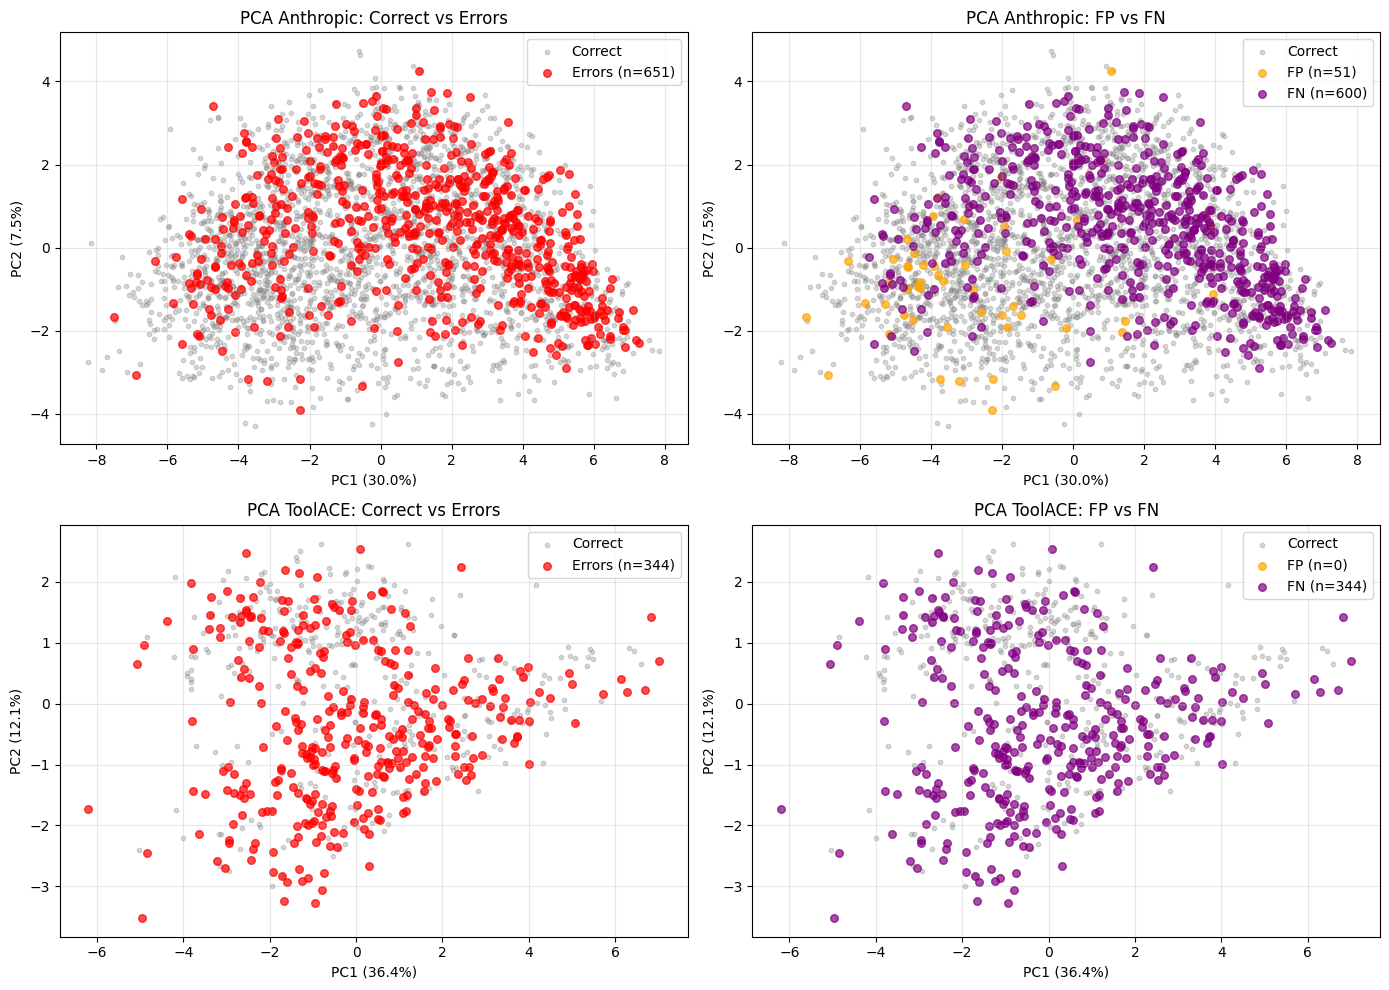

Saved to /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/v2b_llama31_8b_pca_failures_layer12.png


In [7]:
# PCA: Linear separability check for Anthropic and ToolACE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (X, errors, fp, fn, name) in enumerate([
    (X_anthropic, errors_anthropic, fp_anthropic, fn_anthropic, "Anthropic"),
    (X_toolace,   errors_toolace,   fp_toolace,   fn_toolace,   "ToolACE"),
]):
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X)
    
    # Correct vs errors
    ax = axes[row, 0]
    ax.scatter(X_pca[~errors, 0], X_pca[~errors, 1], c='gray', s=10, alpha=0.3, label='Correct')
    ax.scatter(X_pca[errors, 0],  X_pca[errors, 1],  c='red',  s=30, alpha=0.7, label=f'Errors (n={errors.sum()})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'PCA {name}: Correct vs Errors')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # FP vs FN
    ax = axes[row, 1]
    ax.scatter(X_pca[~errors, 0], X_pca[~errors, 1], c='gray',   s=10, alpha=0.3, label='Correct')
    ax.scatter(X_pca[fp, 0],      X_pca[fp, 1],      c='orange', s=30, alpha=0.7, label=f'FP (n={fp.sum()})')
    ax.scatter(X_pca[fn, 0],      X_pca[fn, 1],      c='purple', s=30, alpha=0.7, label=f'FN (n={fn.sum()})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'PCA {name}: FP vs FN')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{CACHE_PREFIX}_pca_failures_layer{LAYER}.png", dpi=150)
plt.show()
print(f"Saved to {FIG_DIR / f'{CACHE_PREFIX}_pca_failures_layer{LAYER}.png'}")

Computing UMAP for Anthropic (n=2984)...


/home/ubuntu/default-filesystem/bluedot-project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for ToolACE (n=734)...


/home/ubuntu/default-filesystem/bluedot-project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


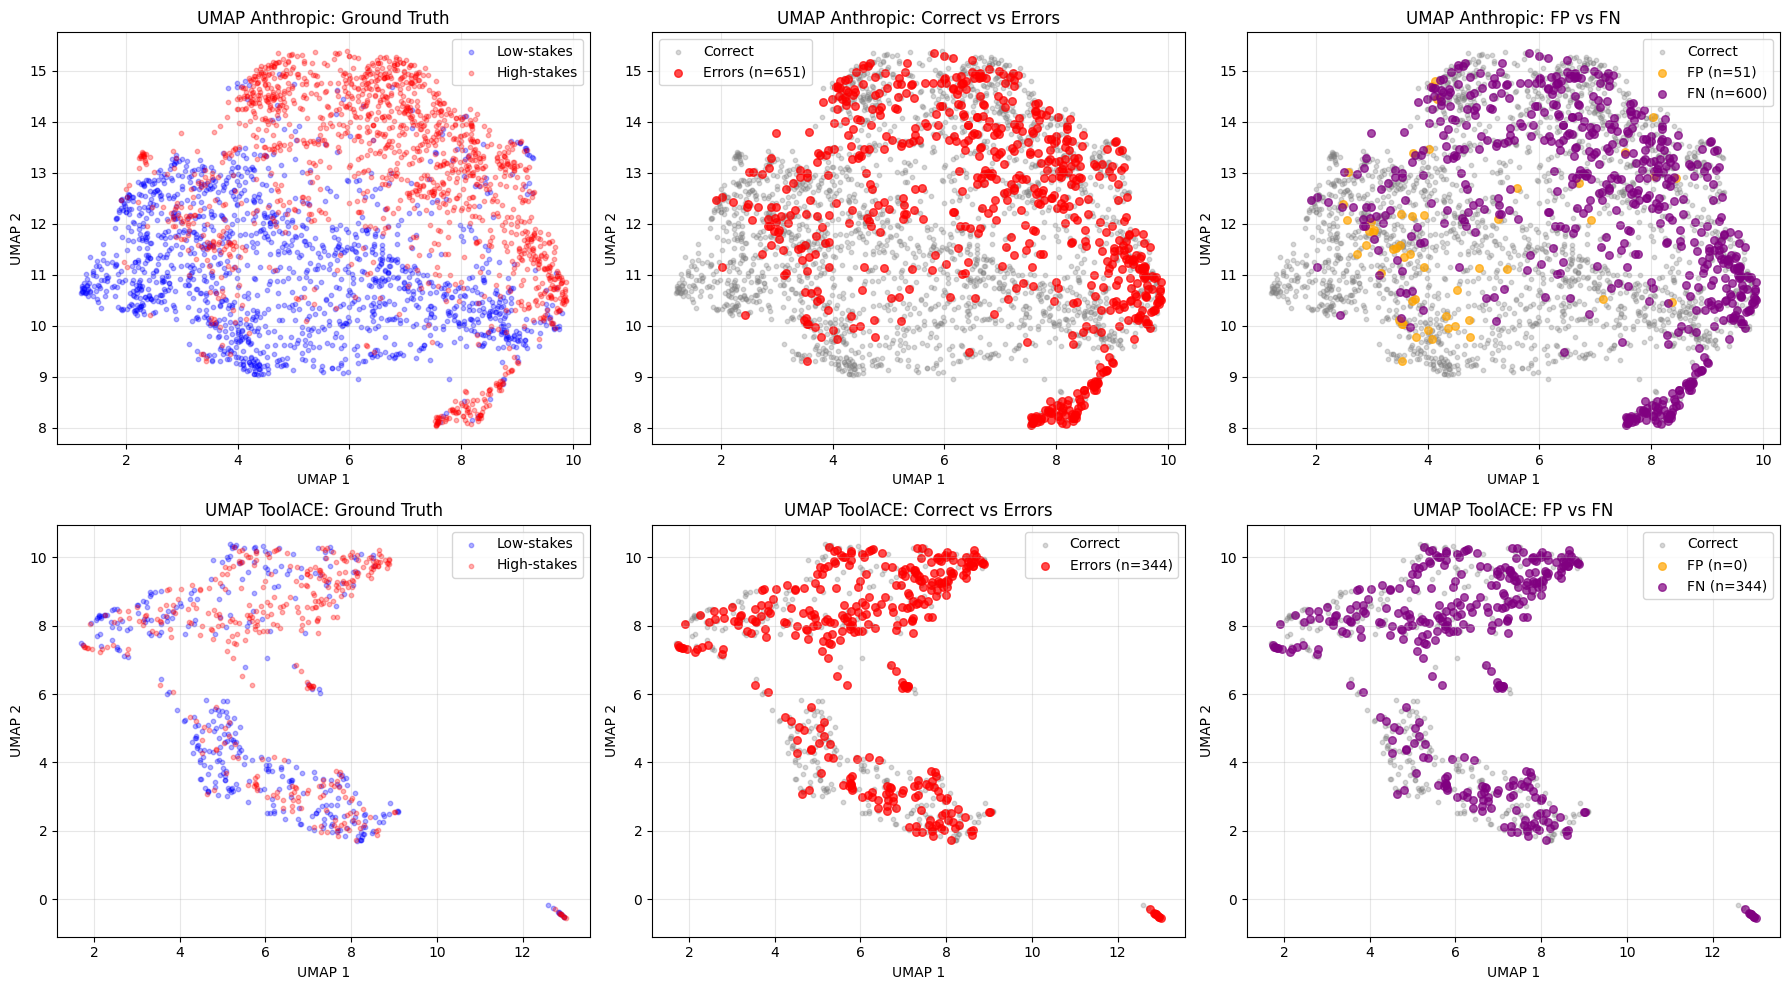

Saved to /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/v2b_llama31_8b_umap_failures_layer12.png


In [8]:
# UMAP: Non-linear clustering for Anthropic and ToolACE
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (X, y, errors, fp, fn, name) in enumerate([
    (X_anthropic, y_anthropic, errors_anthropic, fp_anthropic, fn_anthropic, "Anthropic"),
    (X_toolace,   y_toolace,   errors_toolace,   fp_toolace,   fn_toolace,   "ToolACE"),
]):
    print(f"Computing UMAP for {name} (n={len(X)})...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED, verbose=False)
    X_umap = reducer.fit_transform(X)
    
    # Ground truth
    ax = axes[row, 0]
    ax.scatter(X_umap[y == 0, 0], X_umap[y == 0, 1], c='blue', s=10, alpha=0.3, label='Low-stakes')
    ax.scatter(X_umap[y == 1, 0], X_umap[y == 1, 1], c='red',  s=10, alpha=0.3, label='High-stakes')
    ax.set_title(f'UMAP {name}: Ground Truth')
    ax.legend()
    
    # Correct vs errors
    ax = axes[row, 1]
    ax.scatter(X_umap[~errors, 0], X_umap[~errors, 1], c='gray', s=10, alpha=0.3, label='Correct')
    ax.scatter(X_umap[errors, 0],  X_umap[errors, 1],  c='red',  s=30, alpha=0.7, label=f'Errors (n={errors.sum()})')
    ax.set_title(f'UMAP {name}: Correct vs Errors')
    ax.legend()
    
    # FP vs FN
    ax = axes[row, 2]
    ax.scatter(X_umap[~errors, 0], X_umap[~errors, 1], c='gray',   s=10, alpha=0.3, label='Correct')
    ax.scatter(X_umap[fp, 0],      X_umap[fp, 1],      c='orange', s=30, alpha=0.7, label=f'FP (n={fp.sum()})')
    ax.scatter(X_umap[fn, 0],      X_umap[fn, 1],      c='purple', s=30, alpha=0.7, label=f'FN (n={fn.sum()})')
    ax.set_title(f'UMAP {name}: FP vs FN')
    ax.legend()
    
    for ax in axes[row]:
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{CACHE_PREFIX}_umap_failures_layer{LAYER}.png", dpi=150)
plt.show()
print(f"Saved to {FIG_DIR / f'{CACHE_PREFIX}_umap_failures_layer{LAYER}.png'}")


Anthropic Cosine Similarity to Correct-Mean:
  Correct: 0.8934 +/- 0.0360
  Errors:  0.9000 +/- 0.0311

ToolACE Cosine Similarity to Correct-Mean:
  Correct: 0.9564 +/- 0.0264
  Errors:  0.9537 +/- 0.0290


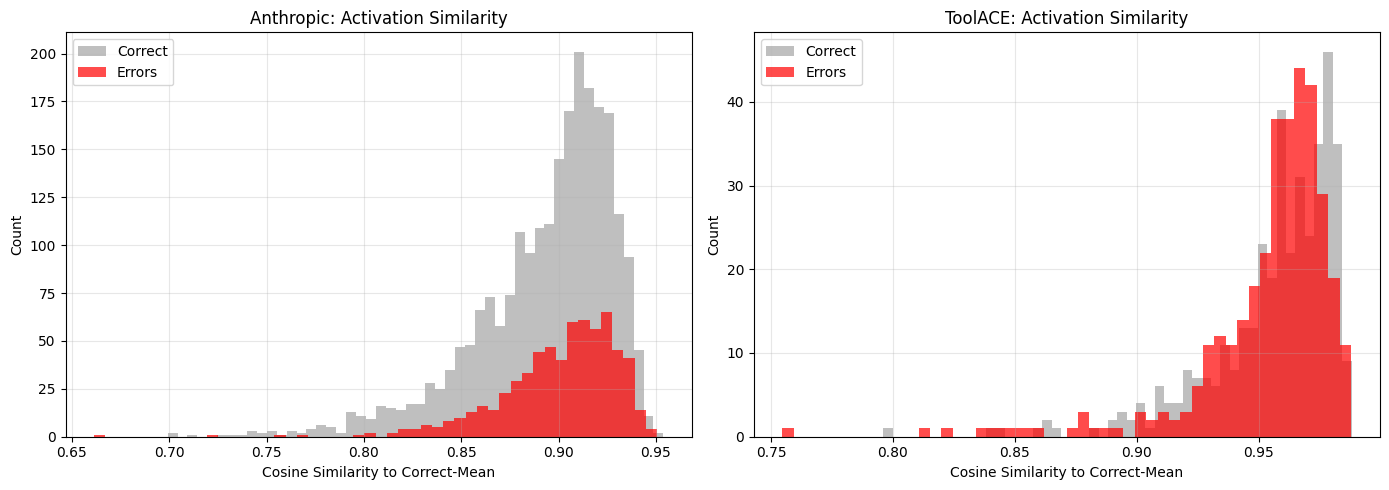

Saved to /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/figures/v2b_llama31_8b_cosine_sim_layer12.png


In [9]:
# Cosine similarity: errors vs correct predictions for Anthropic and ToolACE
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, (X, errors, name) in enumerate([
    (X_anthropic, errors_anthropic, "Anthropic"),
    (X_toolace,   errors_toolace,   "ToolACE"),
]):
    X_correct      = X[~errors]
    X_errors       = X[errors]
    X_correct_mean = X_correct.mean(axis=0, keepdims=True)
    
    cos_correct = cosine_similarity(X_correct, X_correct_mean).flatten()
    cos_errors  = cosine_similarity(X_errors,  X_correct_mean).flatten()
    
    ax = axes[col]
    ax.hist(cos_correct, bins=50, alpha=0.5, label='Correct', color='gray')
    ax.hist(cos_errors,  bins=50, alpha=0.7, label='Errors',  color='red')
    ax.set_xlabel('Cosine Similarity to Correct-Mean')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}: Activation Similarity')
    ax.legend()
    ax.grid(alpha=0.3)
    
    print(f"\n{name} Cosine Similarity to Correct-Mean:")
    print(f"  Correct: {cos_correct.mean():.4f} +/- {cos_correct.std():.4f}")
    print(f"  Errors:  {cos_errors.mean():.4f} +/- {cos_errors.std():.4f}")

plt.tight_layout()
plt.savefig(FIG_DIR / f"{CACHE_PREFIX}_cosine_sim_layer{LAYER}.png", dpi=150)
plt.show()
print(f"Saved to {FIG_DIR / f'{CACHE_PREFIX}_cosine_sim_layer{LAYER}.png'}")

## Part 4: Load Model, SAE, and Extract Per-Token Features

Load Llama Scope SAE (32K features, layer 12 residual stream) and extract SAE features via per-token encoding.

**Per-token SAE encoding:** SAEs are trained on individual token activations. We run the model's forward pass, hook into `input_layernorm`, encode each token through the SAE, then max-pool the sparse features across the sequence. This gives proper sparsity (L0 ~ 50) instead of the ~2 you get from encoding mean-pooled activations.

**Base vs Instruct:** Llama Scope SAEs are trained on **Llama-3.1-8B-Base**. The Llama Scope paper (arXiv:2410.20526) shows no significant degradation for layers 0-30 when applied to Instruct. Our layer 12 is safe.

In [10]:
# Load model + tokenizer (needed for per-token SAE encoding)
from lib.env import get_gpu_vram_gb, recommend_batch_size

model, tokenizer = load_model(MODEL_NAME)
vram_gb          = get_gpu_vram_gb()
sae_batch_size   = max(1, recommend_batch_size(vram_gb, 8) // 2)  # conservative: SAE encoding is memory-heavy

print(f"Model loaded: {MODEL_NAME}")
print(f"VRAM: {vram_gb:.1f} GB, SAE batch size: {sae_batch_size}")

Loading meta-llama/Llama-3.1-8B-Instruct...
  Device: cuda | VRAM: 39.5 GB | Precision: 8-bit


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Layers: 32 | Hidden dim: 4096 | Vocab: 128256
Model loaded: meta-llama/Llama-3.1-8B-Instruct
VRAM: 39.5 GB, SAE batch size: 4


In [11]:
# Load SAE from Llama Scope via SAE Lens
# Note: Llama Scope SAEs are trained on the Base model, not Instruct.
# The paper (arXiv:2410.20526) shows negligible degradation when applying
# Base SAEs to Instruct models for layers 0-30. Layer 12 is safe.
from sae_lens import SAE

setup_hf_auth()  # Ensure HF token is set

# SAE Lens release names (from pretrained_saes.yaml):
#   "llama_scope_lxr_8x"  -> fnlp/Llama3_1-8B-Base-LXR-8x  (residual, 32K features)
#   "llama_scope_lxr_32x" -> fnlp/Llama3_1-8B-Base-LXR-32x (residual, 128K features)
# SAE ID format: "l{layer}r_{expansion}" e.g. "l12r_8x"

SAE_RELEASE  = f"llama_scope_lxr_{SAE_EXPANSION}"      # e.g. "llama_scope_lxr_8x"
SAE_LENS_ID  = f"l{LAYER}r_{SAE_EXPANSION}"             # e.g. "l12r_8x"

print(f"Loading SAE: {SAE_RELEASE} / {SAE_LENS_ID}")
print(f"(HF repo: fnlp/Llama3_1-8B-Base-LXR-{SAE_EXPANSION})")
print("(This may take 1-2 minutes on first download)")

device = "cuda" if torch.cuda.is_available() else "cpu"
sae = SAE.from_pretrained(
    release=SAE_RELEASE,
    sae_id=SAE_LENS_ID,
    device=device
)

n_features = sae.cfg.d_sae
print(f"Loaded SAE with {n_features} features")
print(f"Device: {device}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace
Loading SAE: llama_scope_lxr_8x / l12r_8x
(HF repo: fnlp/Llama3_1-8B-Base-LXR-8x)
(This may take 1-2 minutes on first download)


hyperparams.json: 0.00B [00:00, ?B/s]

Llama3_1-8B-Base-L12R-8x/checkpoints/fin(…):   0%|          | 0.00/537M [00:00<?, ?B/s]

Loaded SAE with 32768 features
Device: cuda


In [12]:
# Extract per-token SAE features for all datasets
# Uses get_sae_features_cached: runs forward pass, hooks into input_layernorm,
# encodes each token through SAE, max-pools features across sequence.
# Results are cached to disk as .npy files.
from lib.activations import get_sae_features_cached

print("Extracting per-token SAE features for synthetic test...")
F_test = get_sae_features_cached(
    model, tokenizer, test_data, LAYER, sae,
    cache_name="test_synthetic", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=sae_batch_size,
)
print(f"  Shape: {F_test.shape}, L0: {(F_test > 0).sum(axis=1).mean():.1f}")

print("Extracting per-token SAE features for Anthropic...")
F_anthropic = get_sae_features_cached(
    model, tokenizer, anthropic_test, LAYER, sae,
    cache_name="anthropic_test", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=sae_batch_size,
)
print(f"  Shape: {F_anthropic.shape}, L0: {(F_anthropic > 0).sum(axis=1).mean():.1f}")

print("Extracting per-token SAE features for ToolACE...")
F_toolace = get_sae_features_cached(
    model, tokenizer, toolace_test, LAYER, sae,
    cache_name="toolace_test", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=sae_batch_size,
)
print(f"  Shape: {F_toolace.shape}, L0: {(F_toolace > 0).sum(axis=1).mean():.1f}")

Extracting per-token SAE features for synthetic test...
Loading SAE features from cache: v2b_llama31_8b_sae_test_synthetic_layer12.npy
  Shape: (2000, 32768), L0: 66.0
Extracting per-token SAE features for Anthropic...
Loading SAE features from cache: v2b_llama31_8b_sae_anthropic_test_layer12.npy
  Shape: (2984, 32768), L0: 111.6
Extracting per-token SAE features for ToolACE...
Loading SAE features from cache: v2b_llama31_8b_sae_toolace_test_layer12.npy
  Shape: (734, 32768), L0: 205.1


## Part 5: Feature Analysis for Failures

Extract top-k active features for Anthropic and ToolACE failure cases. These are the datasets where the probe actually struggles (691 and 201 errors respectively).

In [13]:
# Extract top-k ACTIVE features for errors in Anthropic and ToolACE
# With per-token SAE encoding + max-pooling, we expect L0 ~ 50 active features
# per example. We take the top-k by activation strength.
TOP_K = 10

def get_top_features(feature_matrix, indices, k=TOP_K):
    """Get top-k active (nonzero) features for given indices."""
    top_features = []
    for i in indices:
        f = feature_matrix[i]
        nonzero_mask = f > 0
        nonzero_idx  = np.where(nonzero_mask)[0]
        nonzero_val  = f[nonzero_idx]

        # Sort by activation strength (descending), take top-k
        order   = np.argsort(nonzero_val)[::-1][:k]
        top_idx = nonzero_idx[order]
        top_val = nonzero_val[order]
        top_features.append((top_idx, top_val))
    return top_features

# Anthropic failures
fp_anthropic_idx = np.where(fp_anthropic)[0]
fn_anthropic_idx = np.where(fn_anthropic)[0]
fp_anthropic_top = get_top_features(F_anthropic, fp_anthropic_idx)
fn_anthropic_top = get_top_features(F_anthropic, fn_anthropic_idx)

# ToolACE failures
fp_toolace_idx = np.where(fp_toolace)[0]
fn_toolace_idx = np.where(fn_toolace)[0]
fp_toolace_top = get_top_features(F_toolace, fp_toolace_idx)
fn_toolace_top = get_top_features(F_toolace, fn_toolace_idx)

# Report how many active features per failure
for name, top_list in [("Anthropic FP", fp_anthropic_top), ("Anthropic FN", fn_anthropic_top),
                        ("ToolACE FP", fp_toolace_top),     ("ToolACE FN", fn_toolace_top)]:
    if not top_list:
        print(f"{name:15s}: 0 examples (no errors of this type)")
        continue
    n_active = [len(idx) for idx, _ in top_list]
    print(f"{name:15s}: {len(top_list):4d} examples, "
          f"active features/example: mean={np.mean(n_active):.1f}, min={np.min(n_active)}, max={np.max(n_active)}")

Anthropic FP   :   51 examples, active features/example: mean=10.0, min=10, max=10
Anthropic FN   :  600 examples, active features/example: mean=10.0, min=10, max=10
ToolACE FP     : 0 examples (no errors of this type)
ToolACE FN     :  344 examples, active features/example: mean=10.0, min=10, max=10


In [14]:
# Feature frequency analysis: Which features are most common in failures?
def get_feature_counts(top_features_list):
    """Count how often each feature appears in top-k."""
    counts = Counter()
    for top_idx, top_val in top_features_list:
        counts.update(top_idx)
    return counts

for dataset_name, fp_top, fn_top, fp_idx, fn_idx in [
    ("ANTHROPIC", fp_anthropic_top, fn_anthropic_top, fp_anthropic_idx, fn_anthropic_idx),
    ("TOOLACE",   fp_toolace_top,   fn_toolace_top,   fp_toolace_idx,   fn_toolace_idx),
]:
    fp_counts = get_feature_counts(fp_top)
    fn_counts = get_feature_counts(fn_top)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    
    print(f"\nTop-10 most common features in FALSE POSITIVES (n={len(fp_idx)}):")
    for feat_id, count in fp_counts.most_common(10):
        print(f"  Feature {feat_id:5d}: {count}/{len(fp_idx)} ({100*count/len(fp_idx):.1f}%)")
    
    print(f"\nTop-10 most common features in FALSE NEGATIVES (n={len(fn_idx)}):")
    for feat_id, count in fn_counts.most_common(10):
        print(f"  Feature {feat_id:5d}: {count}/{len(fn_idx)} ({100*count/len(fn_idx):.1f}%)")

# Store for later use
fp_anthropic_counts = get_feature_counts(fp_anthropic_top)
fn_anthropic_counts = get_feature_counts(fn_anthropic_top)
fp_toolace_counts   = get_feature_counts(fp_toolace_top)
fn_toolace_counts   = get_feature_counts(fn_toolace_top)


ANTHROPIC

Top-10 most common features in FALSE POSITIVES (n=51):
  Feature   604: 51/51 (100.0%)
  Feature 17722: 51/51 (100.0%)
  Feature 19230: 51/51 (100.0%)
  Feature  2462: 49/51 (96.1%)
  Feature  2035: 34/51 (66.7%)
  Feature 19651: 18/51 (35.3%)
  Feature 24577: 17/51 (33.3%)
  Feature 30930: 15/51 (29.4%)
  Feature 24624: 14/51 (27.5%)
  Feature  7375: 11/51 (21.6%)

Top-10 most common features in FALSE NEGATIVES (n=600):
  Feature   604: 600/600 (100.0%)
  Feature 17722: 600/600 (100.0%)
  Feature 19230: 600/600 (100.0%)
  Feature  2462: 598/600 (99.7%)
  Feature  6989: 382/600 (63.7%)
  Feature 16646: 254/600 (42.3%)
  Feature  2035: 213/600 (35.5%)
  Feature  9766: 148/600 (24.7%)
  Feature  5401: 141/600 (23.5%)
  Feature 24624: 131/600 (21.8%)

TOOLACE

Top-10 most common features in FALSE POSITIVES (n=0):

Top-10 most common features in FALSE NEGATIVES (n=344):
  Feature   604: 344/344 (100.0%)
  Feature 17722: 344/344 (100.0%)
  Feature 19651: 340/344 (98.8%)
  Featur

In [15]:
# Feature activation strength: Sum of activations per feature across failures
def get_feature_activation_sums(feature_matrix, indices):
    """Sum activation strength per feature across given indices."""
    return feature_matrix[indices].sum(axis=0)

for dataset_name, F, fp_idx, fn_idx in [
    ("ANTHROPIC", F_anthropic, fp_anthropic_idx, fn_anthropic_idx),
    ("TOOLACE",   F_toolace,   fp_toolace_idx,   fn_toolace_idx),
]:
    fp_sums = get_feature_activation_sums(F, fp_idx)
    fn_sums = get_feature_activation_sums(F, fn_idx)
    
    top_fp = np.argsort(fp_sums)[-10:][::-1]
    top_fn = np.argsort(fn_sums)[-10:][::-1]
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    
    print(f"\nTop-10 by ACTIVATION STRENGTH in FP (n={len(fp_idx)}):")
    for feat_id in top_fp:
        print(f"  Feature {feat_id:5d}: total = {fp_sums[feat_id]:.2f}")
    
    print(f"\nTop-10 by ACTIVATION STRENGTH in FN (n={len(fn_idx)}):")
    for feat_id in top_fn:
        print(f"  Feature {feat_id:5d}: total = {fn_sums[feat_id]:.2f}")


ANTHROPIC

Top-10 by ACTIVATION STRENGTH in FP (n=51):
  Feature   604: total = 542.99
  Feature 17722: total = 368.21
  Feature 19230: total = 278.51
  Feature  2462: total = 241.89
  Feature  2035: total = 208.45
  Feature 24624: total = 189.72
  Feature 19651: total = 182.60
  Feature  6989: total = 180.95
  Feature  4413: total = 178.33
  Feature 16646: total = 172.10

Top-10 by ACTIVATION STRENGTH in FN (n=600):
  Feature   604: total = 6221.01
  Feature 17722: total = 4334.84
  Feature 19230: total = 3269.44
  Feature  2462: total = 2830.70
  Feature  6989: total = 2116.92
  Feature 16646: total = 2019.00
  Feature 24624: total = 1972.37
  Feature  5401: total = 1945.39
  Feature 11897: total = 1911.42
  Feature 24508: total = 1882.09

TOOLACE

Top-10 by ACTIVATION STRENGTH in FP (n=0):
  Feature 32767: total = 0.00
  Feature 32766: total = 0.00
  Feature 10913: total = 0.00
  Feature 10914: total = 0.00
  Feature 10915: total = 0.00
  Feature 10916: total = 0.00
  Feature 10917

### Part 5.1: Differential Feature Analysis

The naive frequency/strength analysis above is **confounded** by universally active features — features like "communication" or "emotional reactions" that fire on virtually every input regardless of correctness.

**Confounding** means a variable that correlates with both your target (errors) and the baseline (correct predictions), making it look diagnostic when it's actually just common. If feature X appears in 100% of errors AND 100% of correct predictions, it tells us nothing about why errors happen.

**Solution:** Compare feature prevalence in errors vs correct predictions. A truly diagnostic feature should be significantly more (or less) prevalent in errors than in correct predictions. We compute:
- `error_rate`: fraction of errors where feature appears in top-k
- `correct_rate`: fraction of correct predictions where feature appears in top-k  
- `differential`: error_rate - correct_rate (positive = enriched in errors)

In [17]:
# Differential feature analysis: error prevalence vs correct prevalence
# Filters out universally-active features that confound naive frequency analysis

def differential_feature_analysis(F, error_mask, k=TOP_K, min_count=5):
    """Compare top-k feature prevalence between errors and correct predictions.
    
    Returns DataFrame sorted by absolute differential (most diagnostic first).
    """
    correct_mask = ~error_mask
    error_idx    = np.where(error_mask)[0]
    correct_idx  = np.where(correct_mask)[0]
    
    # Get top-k features for errors and correct predictions
    error_top   = get_top_features(F, error_idx, k=k)
    correct_top = get_top_features(F, correct_idx, k=k)
    
    error_counts   = get_feature_counts(error_top)
    correct_counts = get_feature_counts(correct_top)
    
    # Collect all features that appear in either set
    all_features = set(error_counts.keys()) | set(correct_counts.keys())
    
    rows = []
    for feat_id in all_features:
        e_count = error_counts.get(feat_id, 0)
        c_count = correct_counts.get(feat_id, 0)
        if e_count + c_count < min_count:
            continue
        
        e_rate = e_count / len(error_idx) if len(error_idx) > 0 else 0
        c_rate = c_count / len(correct_idx) if len(correct_idx) > 0 else 0
        
        rows.append({
            "feature_id":   int(feat_id),
            "error_count":  e_count,
            "correct_count": c_count,
            "error_rate":   e_rate,
            "correct_rate": c_rate,
            "differential": e_rate - c_rate,
        })
    
    df = pd.DataFrame(rows).sort_values("differential", key=abs, ascending=False)
    return df


def print_differential_table(df, explanations, n=15):
    """Print enriched, depleted, and confounded features."""
    # Enriched in errors
    enriched = df[df["differential"] > 0].head(n)
    print(f"\n  ENRICHED in errors (more common in errors than correct):")
    print(f"  {'Feature':>8s} {'Err%':>6s} {'Cor%':>6s} {'Diff':>7s}  Explanation")
    print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*7}  {'-'*40}")
    for _, row in enriched.iterrows():
        feat_id = int(row["feature_id"])
        expl    = explanations.get(feat_id, "")[:50]
        print(f"  {feat_id:8d} {row['error_rate']:6.1%} {row['correct_rate']:6.1%} {row['differential']:+7.1%}  {expl}")
    
    # Depleted in errors
    depleted = df[df["differential"] < 0].tail(n).iloc[::-1]
    print(f"\n  DEPLETED in errors (less common in errors than correct):")
    print(f"  {'Feature':>8s} {'Err%':>6s} {'Cor%':>6s} {'Diff':>7s}  Explanation")
    print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*7}  {'-'*40}")
    for _, row in depleted.iterrows():
        feat_id = int(row["feature_id"])
        expl    = explanations.get(feat_id, "")[:50]
        print(f"  {feat_id:8d} {row['error_rate']:6.1%} {row['correct_rate']:6.1%} {row['differential']:+7.1%}  {expl}")
    
    # Confounded
    confounded = df[abs(df["differential"]) < 0.02].sort_values("error_count", ascending=False).head(5)
    if len(confounded) > 0:
        print(f"\n  Confounded (|diff| < 2%, universally active, not diagnostic):")
        for _, row in confounded.iterrows():
            feat_id = int(row["feature_id"])
            expl    = explanations.get(feat_id, "")[:50]
            print(f"    Feature {feat_id}: err={row['error_rate']:.1%} cor={row['correct_rate']:.1%} diff={row['differential']:+.1%} | {expl}")

explanations = {}

# Run differential analysis for each dataset (all errors combined)
for dataset_name, F, error_mask in [
    ("ANTHROPIC", F_anthropic, errors_anthropic),
    ("TOOLACE",   F_toolace,   errors_toolace),
]:
    n_errors  = error_mask.sum()
    n_correct = (~error_mask).sum()
    
    print(f"\n{'='*80}")
    print(f"DIFFERENTIAL FEATURE ANALYSIS: {dataset_name}")
    print(f"  Errors: {n_errors}, Correct: {n_correct}")
    print(f"{'='*80}")
    
    df = differential_feature_analysis(F, error_mask)
    print_differential_table(df, explanations)

# Also run separately for FP vs FN (different failure mechanisms)
for dataset_name, F, fp_mask, fn_mask in [
    ("ANTHROPIC", F_anthropic, fp_anthropic, fn_anthropic),
    ("TOOLACE",   F_toolace,   fp_toolace,   fn_toolace),
]:
    for error_type, mask in [("FALSE POSITIVES", fp_mask), ("FALSE NEGATIVES", fn_mask)]:
        n = mask.sum()
        if n < 5:
            print(f"\n{dataset_name} {error_type}: only {n} examples, skipping")
            continue
        
        print(f"\n{'='*80}")
        print(f"DIFFERENTIAL: {dataset_name} {error_type} (n={n}) vs Correct")
        print(f"{'='*80}")
        
        df = differential_feature_analysis(F, mask)
        print_differential_table(df, explanations, n=10)


DIFFERENTIAL FEATURE ANALYSIS: ANTHROPIC
  Errors: 651, Correct: 2333

  ENRICHED in errors (more common in errors than correct):
   Feature   Err%   Cor%    Diff  Explanation
  -------- ------ ------ -------  ----------------------------------------
      6989  59.8%  44.4%  +15.3%  
     16646  39.6%  25.4%  +14.3%  
      9766  23.0%  15.1%   +7.9%  
     11897  12.9%   6.6%   +6.3%  
      5401  22.0%  15.8%   +6.1%  
     24508   6.8%   3.2%   +3.6%  
     22182   2.0%   0.0%   +2.0%  
     29941   2.0%   0.0%   +2.0%  
     24624  22.3%  20.6%   +1.7%  
     26929   1.4%   0.0%   +1.4%  
     16622   1.2%   0.0%   +1.2%  
       300   1.7%   0.5%   +1.2%  
      1003  11.8%  10.7%   +1.2%  
      5607   4.1%   3.0%   +1.1%  
     21615   1.1%   0.0%   +1.1%  

  DEPLETED in errors (less common in errors than correct):
   Feature   Err%   Cor%    Diff  Explanation
  -------- ------ ------ -------  ----------------------------------------
     23152   0.2%   0.2%   -0.0%  
     16

## Part 6: Interpret Features via Neuronpedia

Look up top features on Neuronpedia to understand what they represent.

**Manual step:** Visit https://www.neuronpedia.org/llama-scope and search for feature IDs.

For automation, we'll create a summary table with Neuronpedia links.

In [18]:
# Fetch explanations from Neuronpedia API
print("Fetching feature explanations from Neuronpedia...")
explanations = fetch_explanations(
    model_id=NEURONPEDIA_MODEL_ID,
    sae_id=NEURONPEDIA_SAE_ID,
    cache_dir=CACHE_DIR,
    force_refresh=False
)

from lib.neuronpedia import neuronpedia_url

for dataset_name, fp_counts, fn_counts, fp_idx, fn_idx in [
    ("ANTHROPIC", fp_anthropic_counts, fn_anthropic_counts, fp_anthropic_idx, fn_anthropic_idx),
    ("TOOLACE",   fp_toolace_counts,   fn_toolace_counts,   fp_toolace_idx,   fn_toolace_idx),
]:
    print(f"\n{'='*80}")
    print(f"FEATURE EXPLANATIONS: {dataset_name}")
    print(f"{'='*80}")
    
    print(f"\n--- FALSE POSITIVES (n={len(fp_idx)}) ---")
    for i, (feat_id, count) in enumerate(fp_counts.most_common(10), 1):
        explanation = explanations.get(feat_id, "No explanation available")
        url = neuronpedia_url(feat_id, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID)
        print(f"\n{i}. Feature {feat_id} ({count}/{len(fp_idx)} = {100*count/len(fp_idx):.1f}%)")
        print(f"   Explanation: {explanation}")
        print(f"   Link: {url}")
    
    print(f"\n--- FALSE NEGATIVES (n={len(fn_idx)}) ---")
    for i, (feat_id, count) in enumerate(fn_counts.most_common(10), 1):
        explanation = explanations.get(feat_id, "No explanation available")
        url = neuronpedia_url(feat_id, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID)
        print(f"\n{i}. Feature {feat_id} ({count}/{len(fn_idx)} = {100*count/len(fn_idx):.1f}%)")
        print(f"   Explanation: {explanation}")
        print(f"   Link: {url}")

Fetching feature explanations from Neuronpedia...
Loaded 905 cached explanations from llama3.1-8b_12-llamascope-res-32k_explanations.json

FEATURE EXPLANATIONS: ANTHROPIC

--- FALSE POSITIVES (n=51) ---

1. Feature 604 (51/51 = 100.0%)
   Explanation: phrases related to communication and community engagement
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/604

2. Feature 17722 (51/51 = 100.0%)
   Explanation:  emotional reactions and expressions related to discussions
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/17722

3. Feature 19230 (51/51 = 100.0%)
   Explanation: references to role-playing games (RPGs) and related gaming concepts
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/19230

4. Feature 2462 (49/51 = 96.1%)
   Explanation:  references to academic articles or publications
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/2462

5. Feature 2035 (34/51 = 66.7%)
   Explanation:  referen

## Part 7: Signal Word Analysis

Identify specific tokens that trigger false positives (like paper's "emergency" example).

In [19]:
# Signal word analysis for Anthropic and ToolACE false positives
import re

signal_words = [
    "emergency", "urgent", "critical", "danger", "crisis", "threat",
    "illegal", "harm", "kill", "attack", "weapon", "terror",
    "hack", "steal", "fraud", "scam", "launder",
    "suicide", "abuse", "violence", "drug", "bomb", "exploit",
]

for dataset_name, data, fp_idx in [
    ("ANTHROPIC", anthropic_test, fp_anthropic_idx),
    ("TOOLACE",   toolace_test,   fp_toolace_idx),
]:
    fp_examples = [data[i] for i in fp_idx]
    fp_texts    = [next((m["content"] for m in ex.messages if m["role"] == "user"), "") for ex in fp_examples]
    
    word_counts   = Counter()
    examples_with = []
    
    for i, text in enumerate(fp_texts):
        text_lower = text.lower()
        for word in signal_words:
            if re.search(rf"\b{word}\b", text_lower):
                word_counts[word] += 1
                if len(examples_with) < 5:
                    examples_with.append((i, word, text[:200]))
    
    print(f"\n{'='*60}")
    print(f"Signal Words in {dataset_name} False Positives (n={len(fp_idx)})")
    print(f"{'='*60}")
    
    if word_counts:
        for word, count in word_counts.most_common(15):
            print(f"  '{word}': {count} ({100*count/len(fp_texts):.1f}% of FPs)")
        
        print(f"\nExamples:")
        for i, word, text in examples_with[:3]:
            print(f"\n  [{fp_idx[i]}] Signal: '{word}'")
            print(f"  {text}...")
    else:
        print("  No signal words found in FP texts.")


Signal Words in ANTHROPIC False Positives (n=51)
  No signal words found in FP texts.

Signal Words in TOOLACE False Positives (n=0)
  No signal words found in FP texts.


## Part 8: Annotated Failure Examples

Create human-readable summaries of failures with SAE explanations.

In [20]:
# Annotated failure examples from Anthropic and ToolACE
np.random.seed(RANDOM_SEED)

def annotate_example(idx, example, prob, top_features, explanations):
    """Create annotated failure summary with feature explanations."""
    user_msg = next((m["content"] for m in example.messages if m["role"] == "user"), "")
    top_idx, top_val = top_features
    
    print(f"\n{'='*80}")
    print(f"Example ID: {example.id}")
    print(f"Prediction: {prob:.3f} | True label: {example.label}")
    print(f"Text (first 300 chars): {user_msg[:300]}...")
    print(f"\nTop-{TOP_K} SAE Features:")
    for i, (feat_id, val) in enumerate(zip(top_idx, top_val)):
        print(f"  {i+1}. {format_feature_with_explanation(feat_id, val, explanations, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID, max_length=120)}")

for dataset_name, data, probs, fp_idx, fn_idx, fp_top, fn_top in [
    ("ANTHROPIC", anthropic_test, probs_anthropic, fp_anthropic_idx, fn_anthropic_idx, fp_anthropic_top, fn_anthropic_top),
    ("TOOLACE",   toolace_test,   probs_toolace,   fp_toolace_idx,   fn_toolace_idx,   fp_toolace_top,   fn_toolace_top),
]:
    n_fp_sample = min(5, len(fp_idx))
    n_fn_sample = min(5, len(fn_idx))
    
    sample_fp = np.random.choice(len(fp_idx), size=n_fp_sample, replace=False)
    sample_fn = np.random.choice(len(fn_idx), size=n_fn_sample, replace=False)
    
    print(f"\n{'#'*80}")
    print(f"# {dataset_name} - FALSE POSITIVES (sampled {n_fp_sample}/{len(fp_idx)})")
    print(f"{'#'*80}")
    for s in sample_fp:
        idx = fp_idx[s]
        annotate_example(idx, data[idx], probs[idx], fp_top[s], explanations)
    
    print(f"\n{'#'*80}")
    print(f"# {dataset_name} - FALSE NEGATIVES (sampled {n_fn_sample}/{len(fn_idx)})")
    print(f"{'#'*80}")
    for s in sample_fn:
        idx = fn_idx[s]
        annotate_example(idx, data[idx], probs[idx], fn_top[s], explanations)


################################################################################
# ANTHROPIC - FALSE POSITIVES (sampled 5/51)
################################################################################

Example ID: train_10781_rejected
Prediction: 0.574 | True label: 0
Text (first 300 chars): what is the meaning of whore...

Top-10 SAE Features:
  1. Feature   604 (act=10.270): phrases related to communication and community engagement
            https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/604
  2. Feature 17722 (act=7.086):  emotional reactions and expressions related to discussions
            https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/17722
  3. Feature 19230 (act=5.482): references to role-playing games (RPGs) and related gaming concepts
            https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/19230
  4. Feature 12649 (act=5.311): phrases that indicate the significance or impact of something
            https://www.neuronp

## Part 9: Summary & Recommendations

Statistical summary and next steps.

In [23]:
# Save results to JSON
results = {
    "model":      MODEL_NAME,
    "layer":      LAYER,
    "sae_id":     SAE_ID,
    "n_features": int(n_features),
    "error_counts": {
        "synthetic":  {"total": int(errors_test.sum()),      "fp": int(fp_test.sum()),      "fn": int(fn_test.sum())},
        "anthropic":  {"total": int(errors_anthropic.sum()), "fp": int(fp_anthropic.sum()), "fn": int(fn_anthropic.sum())},
        "toolace":    {"total": int(errors_toolace.sum()),   "fp": int(fp_toolace.sum()),   "fn": int(fn_toolace.sum())},
    },
    "anthropic_top_fp_features": [(int(f), int(c)) for f, c in fp_anthropic_counts.most_common(20)],
    "anthropic_top_fn_features": [(int(f), int(c)) for f, c in fn_anthropic_counts.most_common(20)],
    "toolace_top_fp_features":   [(int(f), int(c)) for f, c in fp_toolace_counts.most_common(20)],
    "toolace_top_fn_features":   [(int(f), int(c)) for f, c in fn_toolace_counts.most_common(20)],
    "sparsity_l0_anthropic": float((F_anthropic > 0).sum(axis=1).mean()),
    "sparsity_l0_toolace":   float((F_toolace > 0).sum(axis=1).mean()),
}

if EVAL_INDONESIAN:
    results["cross_lingual_anthropic"] = {
        "n_aligned":      len(flips_anthropic["aligned"]),
        "both_wrong":     len(flips_anthropic["both_wrong_idx"]),
        "en_ok_id_fail":  len(flips_anthropic["en_ok_id_fail_idx"]),
        "en_fail_id_ok":  len(flips_anthropic["en_fail_id_ok_idx"]),
    }
    results["cross_lingual_toolace"] = {
        "n_aligned":      len(flips_toolace["aligned"]),
        "both_wrong":     len(flips_toolace["both_wrong_idx"]),
        "en_ok_id_fail":  len(flips_toolace["en_ok_id_fail_idx"]),
        "en_fail_id_ok":  len(flips_toolace["en_fail_id_ok_idx"]),
    }

output_path = CACHE_DIR / f"{CACHE_PREFIX}_failure_analysis_layer{LAYER}.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {output_path.name}")
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Anthropic: {errors_anthropic.sum()} errors ({fp_anthropic.sum()} FP, {fn_anthropic.sum()} FN) out of {len(anthropic_test)}")
print(f"ToolACE:   {errors_toolace.sum()} errors ({fp_toolace.sum()} FP, {fn_toolace.sum()} FN) out of {len(toolace_test)}")
print(f"Synthetic: {errors_test.sum()} errors (not analyzed — too easy)")
print(f"\nSAE sparsity (L0): Anthropic={results['sparsity_l0_anthropic']:.1f}, ToolACE={results['sparsity_l0_toolace']:.1f}")

for name, counts, idx in [("Anthropic FP", fp_anthropic_counts, fp_anthropic_idx),
                           ("ToolACE FP",   fp_toolace_counts,   fp_toolace_idx)]:
    top = counts.most_common(1)
    if top:
        print(f"Top {name} feature: {top[0][0]} ({top[0][1]}/{len(idx)} cases)")
    else:
        print(f"Top {name} feature: N/A (0 false positives)")

Results saved to v2b_llama31_8b_failure_analysis_layer12.json

SUMMARY
Anthropic: 651 errors (51 FP, 600 FN) out of 2984
ToolACE:   344 errors (0 FP, 344 FN) out of 734
Synthetic: 41 errors (not analyzed — too easy)

SAE sparsity (L0): Anthropic=111.6, ToolACE=205.1
Top Anthropic FP feature: 604 (51/51 cases)
Top ToolACE FP feature: N/A (0 false positives)


## Part 10: Export All Errors to cache/outputs/

Save detailed error records (text, prediction, label, top SAE features, explanations) as JSONL for downstream use in write-ups and further analysis.

In [24]:
# Export all error examples with metadata, predictions, and top SAE features
OUTPUT_DIR = CACHE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def build_error_records(data, probs, preds, labels, fp_mask, fn_mask,
                        top_fp_list, top_fn_list, fp_idx, fn_idx,
                        explanations, dataset_name):
    """Build list of dicts for all errors in a dataset."""
    records = []

    for local_i, global_i in enumerate(fp_idx):
        example  = data[global_i]
        user_msg = next((m["content"] for m in example.messages if m["role"] == "user"), "")
        top_idx, top_val = top_fp_list[local_i]
        features = [
            {"feature_id": int(fid), "activation": float(val),
             "explanation": explanations.get(int(fid), "")}
            for fid, val in zip(top_idx, top_val)
        ]
        records.append({
            "dataset":    dataset_name,
            "error_type": "false_positive",
            "example_id": example.id,
            "true_label": int(labels[global_i]),
            "pred_label": int(preds[global_i]),
            "prob":       float(probs[global_i]),
            "user_text":  user_msg,
            "top_sae_features": features,
        })

    for local_i, global_i in enumerate(fn_idx):
        example  = data[global_i]
        user_msg = next((m["content"] for m in example.messages if m["role"] == "user"), "")
        top_idx, top_val = top_fn_list[local_i]
        features = [
            {"feature_id": int(fid), "activation": float(val),
             "explanation": explanations.get(int(fid), "")}
            for fid, val in zip(top_idx, top_val)
        ]
        records.append({
            "dataset":    dataset_name,
            "error_type": "false_negative",
            "example_id": example.id,
            "true_label": int(labels[global_i]),
            "pred_label": int(preds[global_i]),
            "prob":       float(probs[global_i]),
            "user_text":  user_msg,
            "top_sae_features": features,
        })

    return records

all_error_records = []

for dataset_name, data, probs, preds, labels, fp_m, fn_m, fp_top, fn_top, fp_i, fn_i in [
    ("en_anthropic", anthropic_test, probs_anthropic, preds_anthropic, y_anthropic,
     fp_anthropic, fn_anthropic, fp_anthropic_top, fn_anthropic_top, fp_anthropic_idx, fn_anthropic_idx),
    ("en_toolace", toolace_test, probs_toolace, preds_toolace, y_toolace,
     fp_toolace, fn_toolace, fp_toolace_top, fn_toolace_top, fp_toolace_idx, fn_toolace_idx),
    ("en_synthetic", test_data, probs_test, preds_test, y_test,
     fp_test, fn_test,
     get_top_features(F_test, np.where(fp_test)[0]),
     get_top_features(F_test, np.where(fn_test)[0]),
     np.where(fp_test)[0], np.where(fn_test)[0]),
]:
    recs = build_error_records(
        data, probs, preds, labels, fp_m, fn_m, fp_top, fn_top, fp_i, fn_i,
        explanations, dataset_name,
    )
    all_error_records.extend(recs)

# Write JSONL
output_path = OUTPUT_DIR / f"{CACHE_PREFIX}_all_errors_layer{LAYER}.jsonl"
with open(output_path, "w") as f:
    for rec in all_error_records:
        f.write(json.dumps(rec) + "\n")

print(f"Exported {len(all_error_records)} error records to {output_path}")
print(f"  Anthropic: {sum(1 for r in all_error_records if r['dataset'] == 'en_anthropic')} errors")
print(f"  ToolACE:   {sum(1 for r in all_error_records if r['dataset'] == 'en_toolace')} errors")
print(f"  Synthetic: {sum(1 for r in all_error_records if r['dataset'] == 'en_synthetic')} errors")

Exported 1036 error records to /lambda/nfs/default-filesystem/bluedot-project/experiments/cache/outputs/v2b_llama31_8b_all_errors_layer12.jsonl
  Anthropic: 651 errors
  ToolACE:   344 errors
  Synthetic: 41 errors
